In [1]:
# GPT-1 vs Transformer 아키텍처 변경사항

#GPT-1은 기존 Transformer에서 Encoder를 제거하고
#Decoder만 사용하는 구조입니다.

In [2]:
# ============================================================
# GPT-1 vs Transformer 아키텍처 변경사항 (블록 단위)
# ============================================================

# [1. Encoder 블록]
# - Transformer : Encoder 존재 (Embedding → Multi-Head Attention → FFN → LayerNorm)
# - GPT-1       : Encoder 제거
# - 변경사항    : Encoder 블록 통째로 삭제

# [2. Cross Attention 블록]
# - Transformer : Decoder 안에 Cross Attention 존재 (인코더 출력을 참조)
# - GPT-1       : Cross Attention 제거
# - 변경사항    : 인코더가 없으므로 Cross Attention 불필요 → 삭제

# [3. Masked Multi-Head Self-Attention 블록]
# - Transformer : 존재 (미래 토큰 참조 방지)
# - GPT-1       : 존재
# - 변경사항    : 유지 (GPT-1의 핵심 블록)

# [4. Feed Forward 블록]
# - Transformer : 존재
# - GPT-1       : 존재
# - 변경사항    : 유지

# [5. Layer Normalization 블록]
# - Transformer : Attention/FFN 이후에 적용 (Post-LN)
# - GPT-1       : Attention/FFN 이전에 적용 (Pre-LN)
# - 변경사항    : 적용 순서 변경

# [6. 최종 구조 비교]
# - Transformer : Encoder + Decoder (입력 2개: src, tgt)
# - GPT-1       : Decoder Only      (입력 1개: x)
# - 변경사항    : forward(src, tgt, ...) → forward(x, mask)

In [3]:
# ============================================================
# [Transformer → GPT-1 변경사항 주석]
# ============================================================

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        # ✅ [유지] Masked Self-Attention: 미래 토큰 차단 (GPT-1 핵심 블록)
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        # ❌ [제거] Cross Attention: Encoder가 없으므로 GPT-1에서 불필요
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        # ✅ [유지] Feed Forward Network
        self.ffn  = nn.Sequential(nn.Linear(d_model, ff_dim), nn.ReLU(), nn.Linear(ff_dim, d_model))
        # ✅ [유지] Self-Attention용 LayerNorm
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        # ❌ [제거] Cross Attention용 LayerNorm: mha2 제거로 함께 불필요
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        # ✅ [유지] FFN용 LayerNorm
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop1 = nn.Dropout(dropout)
        # ❌ [제거] Cross Attention용 Dropout: mha2 제거로 함께 불필요
        self.drop2 = nn.Dropout(dropout)
        # ✅ [유지] FFN용 Dropout
        self.drop3 = nn.Dropout(dropout)

    # ❌ [제거] enc_out, padding_mask 인자: Encoder 없으므로 GPT-1에서 불필요
    def forward(self, x, enc_out, look_ahead_mask=None, padding_mask=None):
        # ✅ [유지] Masked Self-Attention + Residual + LayerNorm
        x = self.norm1(x + self.drop1(self.mha1(x, x, x, look_ahead_mask)))
        # ❌ [제거] Cross Attention 블록 전체
        x = self.norm2(x + self.drop2(self.mha2(x, enc_out, enc_out, padding_mask)))
        # ✅ [유지] FFN + Residual + LayerNorm
        return self.norm3(x + self.drop3(self.ffn(x)))


class Encoder(nn.Module):
    # ❌ [제거] Encoder 클래스 전체: GPT-1은 Decoder Only 구조
    pass

NameError: name 'nn' is not defined

In [1]:
# ============================================================
# GPT-1 구현 (Decoder Only Transformer)
# 기반 코드: 어제 구현한 Transformer Chatbot Decoder
# 변경사항: Encoder 제거, Decoder Only 구조로 수정
# ============================================================

!pip install sentencepiece --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm
import pandas as pd
import re
import math
from sklearn.model_selection import train_test_split

# ── 디바이스 설정 ──────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

# ── 특수 토큰 ID ───────────────────────────────────────────
PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
UNK_ID = 3
SEP_ID = 4  # Q와 A를 구분하는 토큰 (GPT-1 추가)

# ── 하이퍼파라미터 ─────────────────────────────────────────
# 논문 원본: num_layers=12, d_model=768, num_heads=12
# 실습용으로 축소 (메모리/속도 고려)
MAX_LEN    = 50    # Q + SEP + A 합친 길이
VOCAB_SIZE = 8000
NUM_LAYERS = 4     # 논문: 12
D_MODEL    = 256   # 논문: 768
NUM_HEADS  = 8     # 논문: 12
D_FF       = 1024  # 논문: 3072 (D_MODEL * 4)
DROPOUT    = 0.1
BATCH_SIZE = 64
EPOCHS     = 30

! mkdir -p ~/work/transformer_chatbot/data/ && cd ~/work/transformer_chatbot/data/
! wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv

사용 디바이스: cuda
--2026-06-23 08:24:58--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-06-23 08:24:58--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv’

ChatbotData.csv     100%[===================>] 868.99K  4.96MB/s    in 0.2s    

2026-06-23 08:24:59 (4.96 MB/s) - ‘ChatbotData.csv’ saved [889842/889842]



In [2]:
# Step 2. 데이터 로드 + 전처리
DATA_DIR = '/home/jovyan/work/transformer_chatbot/data/'

df = pd.read_csv(DATA_DIR + 'ChatbotData.csv')
df = df.dropna()

def preprocess_ko(text):
    text = re.sub(r"[^가-힣a-zA-Z0-9?.!,\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['Q'] = df['Q'].apply(preprocess_ko)
df['A'] = df['A'].apply(preprocess_ko)
df = df[(df['Q'] != '') & (df['A'] != '')]
print(f"전처리 후 데이터 수: {len(df):,}개")
print(df.head(3))

전처리 후 데이터 수: 11,823개
              Q            A  label
0        12시 땡!   하루가 또 가네요.      0
1   1지망 학교 떨어졌어    위로해 드립니다.      0
2  3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0


In [3]:
# Step 3. SentencePiece 토크나이저
# GPT-1은 Q+A를 하나로 이어붙이므로 SEP 토큰을 vocab에 추가

corpus_path = DATA_DIR + 'gpt_corpus.txt'
with open(corpus_path, 'w', encoding='utf-8') as f:
    for _, row in df.iterrows():
        f.write(row['Q'].strip() + '\n')
        f.write(row['A'].strip() + '\n')

spm.SentencePieceTrainer.train(
    input                = corpus_path,
    model_prefix         = DATA_DIR + 'gpt_spm',
    vocab_size           = VOCAB_SIZE,
    character_coverage   = 0.9995,
    model_type           = 'bpe',
    pad_id               = PAD_ID,
    bos_id               = BOS_ID,
    eos_id               = EOS_ID,
    unk_id               = UNK_ID,
    pad_piece            = '[PAD]',
    bos_piece            = '[BOS]',
    eos_piece            = '[EOS]',
    unk_piece            = '[UNK]',
    user_defined_symbols = '[SEP]',  # Q와 A 구분 토큰
)

sp = spm.SentencePieceProcessor()
sp.load(DATA_DIR + 'gpt_spm.model')

SEP_ID = sp.piece_to_id('[SEP]')
print(f"vocab 크기: {sp.get_piece_size()}")
print(f"SEP_ID: {SEP_ID}")
print(f"토크나이징 확인: {sp.encode_as_pieces('오늘 기분이 너무 안좋아')}")

vocab 크기: 8000
SEP_ID: 4
토크나이징 확인: ['▁오늘', '▁기분이', '▁너무', '▁안좋아']


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/jovyan/work/transformer_chatbot/data/gpt_corpus.txt
  input_format: 
  model_prefix: /home/jovyan/work/transformer_chatbot/data/gpt_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [SEP]
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: [UNK]
 

In [4]:
# Step 4. Dataset
# GPT-1 방식: Q + [SEP] + A 를 하나의 시퀀스로 이어붙임
# 기존 Transformer: encoder_input / decoder_input / label 3개로 분리
# GPT-1: input / label 2개 (한 칸씩 밀린 구조)

class GPTDataset(Dataset):
    def __init__(self, df, sp, max_len):
        self.data = []
        for _, row in df.iterrows():
            # [BOS] Q [SEP] A [EOS] 형태로 이어붙임
            q_ids = sp.encode_as_ids(row['Q'])
            a_ids = sp.encode_as_ids(row['A'])
            ids = [BOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]

            # max_len 맞게 자르거나 패딩
            ids = ids[:max_len]
            ids = ids + [PAD_ID] * (max_len - len(ids))

            # input: 마지막 토큰 제외
            # label: 첫 토큰 제외 (한 칸 앞 토큰 예측)
            input_ids = ids[:-1]
            label_ids = ids[1:]

            self.data.append((
                torch.tensor(input_ids, dtype=torch.long),
                torch.tensor(label_ids, dtype=torch.long),
            ))

    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

# 학습/검증 분리
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
train_dataset = GPTDataset(train_df, sp, MAX_LEN)
val_dataset   = GPTDataset(val_df,   sp, MAX_LEN)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

print(f"학습 데이터: {len(train_dataset):,}개")
print(f"검증 데이터: {len(val_dataset):,}개")

# 샘플 확인
sample_input, sample_label = train_dataset[0]
print(f"\n입력 토큰: {sp.decode(sample_input.tolist())}")
print(f"레이블 토큰: {sp.decode(sample_label.tolist())}")

학습 데이터: 10,640개
검증 데이터: 1,183개

입력 토큰: 나한테 질리면 어쩌지 걱정돼[SEP] 당신의 겉모습이 아닌 진정한 내면의 모습을 보여주세요.
레이블 토큰: 나한테 질리면 어쩌지 걱정돼[SEP] 당신의 겉모습이 아닌 진정한 내면의 모습을 보여주세요.


In [5]:
# 실제로 한 칸 밀렸는지 토큰 ID로 확인
print(f"입력 ID 앞 5개: {sample_input[:5].tolist()}")
print(f"레이블 ID 앞 5개: {sample_label[:5].tolist()}")
# 입력 첫 토큰이 BOS(1), 레이블 첫 토큰은 그 다음 토큰이어야 정상

입력 ID 앞 5개: [1, 544, 564, 1785, 2026]
레이블 ID 앞 5개: [544, 564, 1785, 2026, 2116]


In [6]:
# Step 5. GPT-1 모델
# 기존 Transformer 대비 변경사항:
# - Encoder 제거
# - Cross Attention 제거
# - Decoder Only 구조

# 5-1. Scaled Dot Product Attention (기존과 동일)
def scaled_dot_product_attention(query, key, value, mask=None):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, value)

# 5-2. Multi Head Attention (기존과 동일)
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.depth     = d_model // num_heads
        self.q_dense   = nn.Linear(d_model, d_model)
        self.k_dense   = nn.Linear(d_model, d_model)
        self.v_dense   = nn.Linear(d_model, d_model)
        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def forward(self, query, key, value, mask=None):
        B = query.size(0)
        q = self.split_heads(self.q_dense(query), B)
        k = self.split_heads(self.k_dense(key),   B)
        v = self.split_heads(self.v_dense(value),  B)
        out = scaled_dot_product_attention(q, k, v, mask)
        out = out.permute(0, 2, 1, 3).contiguous().view(B, -1, self.num_heads * self.depth)
        return self.out_dense(out)

# 5-3. GPT DecoderLayer
# 변경: Cross Attention(mha2), norm2, drop2 제거
class GPTDecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        # ✅ 유지: Masked Self-Attention
        self.mha   = MultiHeadAttention(d_model, num_heads)
        # ✅ 유지: Feed Forward
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),               # GPT-1은 ReLU 대신 GELU 사용
            nn.Linear(d_ff, d_model)
        )
        # ✅ 유지: Layer Norm 2개 (Self-Attention용, FFN용)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # ✅ 유지: Masked Self-Attention + Residual + LayerNorm
        x = self.norm1(x + self.drop1(self.mha(x, x, x, mask)))
        # ✅ 유지: FFN + Residual + LayerNorm
        x = self.norm2(x + self.drop2(self.ffn(x)))
        return x

# 5-4. GPT 전체 모델
# 변경: Encoder 제거, 입력 1개(x)만 받음
class GPT(nn.Module):
    def __init__(self, vocab_size, num_layers, d_model, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        # 토큰 임베딩 + 위치 임베딩 (논문 수식 h0 = UWe + Wp)
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_emb   = nn.Embedding(max_len, d_model)  # 학습 가능한 위치 임베딩
        self.drop      = nn.Dropout(dropout)
        self.layers    = nn.ModuleList([
            GPTDecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm    = nn.LayerNorm(d_model, eps=1e-6)
        self.out     = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        B, T = x.size()

        # 위치 인덱스 생성
        pos  = torch.arange(T, device=x.device).unsqueeze(0)

        # Look-ahead mask 생성 (미래 토큰 차단)
        mask = torch.tril(torch.ones(T, T, device=x.device)).unsqueeze(0).unsqueeze(0)

        # 임베딩
        x = self.drop(self.token_emb(x) + self.pos_emb(pos))

        # Decoder Layer 통과
        for layer in self.layers:
            x = layer(x, mask)

        x = self.norm(x)
        return self.out(x)  # (B, T, vocab_size)

# 모델 초기화 및 확인
model = GPT(
    vocab_size = VOCAB_SIZE,
    num_layers = NUM_LAYERS,
    d_model    = D_MODEL,
    num_heads  = NUM_HEADS,
    d_ff       = D_FF,
    max_len    = MAX_LEN,
).to(device)

print(f"파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# 동작 확인
sample_x = torch.randint(0, VOCAB_SIZE, (2, MAX_LEN - 1)).to(device)
out = model(sample_x)
print(f"모델 출력 shape: {out.shape}")  # (2, 49, 8000)

파라미터 수: 7,276,352
모델 출력 shape: torch.Size([2, 49, 8000])


In [7]:
# Step 6. 학습 루프

# PAD 토큰은 loss 계산에서 제외
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for input_ids, label_ids in loader:
        input_ids = input_ids.to(device)
        label_ids = label_ids.to(device)

        optimizer.zero_grad()
        output = model(input_ids)  # (B, T, vocab_size)

        # loss 계산: (B*T, vocab_size) vs (B*T)
        loss = criterion(output.view(-1, VOCAB_SIZE), label_ids.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for input_ids, label_ids in loader:
            input_ids = input_ids.to(device)
            label_ids = label_ids.to(device)
            output = model(input_ids)
            loss = criterion(output.view(-1, VOCAB_SIZE), label_ids.view(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

# 학습 시작
best_val_loss       = float('inf')
early_stop_count    = 0
EARLY_STOP_PATIENCE = 5

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss   = eval_epoch(model,  val_loader,   criterion)

    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        early_stop_count = 0
        torch.save(model.state_dict(), DATA_DIR + 'gpt1_best.pt')
        print(f"           → 모델 저장 (Val Loss: {val_loss:.4f})")
    else:
        early_stop_count += 1
        if early_stop_count >= EARLY_STOP_PATIENCE:
            print(f"\n{EARLY_STOP_PATIENCE} epoch 개선 없음 → 조기 종료")
            break

print(f"\n학습 완료 | Best Val Loss: {best_val_loss:.4f}")

Epoch 001 | Train Loss: 6.9529 | Val Loss: 6.4205
           → 모델 저장 (Val Loss: 6.4205)
Epoch 002 | Train Loss: 6.2523 | Val Loss: 6.1936
           → 모델 저장 (Val Loss: 6.1936)
Epoch 003 | Train Loss: 6.0436 | Val Loss: 6.0532
           → 모델 저장 (Val Loss: 6.0532)
Epoch 004 | Train Loss: 5.8868 | Val Loss: 5.9462
           → 모델 저장 (Val Loss: 5.9462)
Epoch 005 | Train Loss: 5.7458 | Val Loss: 5.8553
           → 모델 저장 (Val Loss: 5.8553)
Epoch 006 | Train Loss: 5.6193 | Val Loss: 5.7769
           → 모델 저장 (Val Loss: 5.7769)
Epoch 007 | Train Loss: 5.4977 | Val Loss: 5.7067
           → 모델 저장 (Val Loss: 5.7067)
Epoch 008 | Train Loss: 5.3850 | Val Loss: 5.6386
           → 모델 저장 (Val Loss: 5.6386)
Epoch 009 | Train Loss: 5.2757 | Val Loss: 5.5820
           → 모델 저장 (Val Loss: 5.5820)
Epoch 010 | Train Loss: 5.1713 | Val Loss: 5.5235
           → 모델 저장 (Val Loss: 5.5235)
Epoch 011 | Train Loss: 5.0745 | Val Loss: 5.4724
           → 모델 저장 (Val Loss: 5.4724)
Epoch 012 | Train Loss: 4.9730 |

In [8]:
# Step 7. 텍스트 생성으로 모델 동작 확인

def generate(model, sp, prompt, max_new_tokens=30):
    model.eval()
    # 입력 문장 토크나이징
    input_ids = [BOS_ID] + sp.encode_as_ids(prompt) + [SEP_ID]
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            output = model(input_tensor)
            # 마지막 토큰의 확률 분포에서 다음 토큰 선택
            next_token = output[0, -1, :].argmax(dim=-1).item()
            if next_token == EOS_ID:
                break
            input_tensor = torch.cat([
                input_tensor,
                torch.tensor([[next_token]], device=device)
            ], dim=1)

    # SEP 이후만 답변으로 추출
    generated = input_tensor[0].tolist()
    sep_idx   = generated.index(SEP_ID) if SEP_ID in generated else 0
    answer    = sp.decode(generated[sep_idx + 1:])
    return answer

# 테스트
test_prompts = ["오늘 기분이 너무 안좋아", "사랑이 뭔지 모르겠어", "밥 먹기 싫다"]
for prompt in test_prompts:
    print(f"Q: {prompt}")
    print(f"A: {generate(model, sp, prompt)}")
    print()

Q: 오늘 기분이 너무 안좋아
A: 잘 될 거예요.

Q: 사랑이 뭔지 모르겠어
A: 자신을 비난하지 마세요.

Q: 밥 먹기 싫다
A: 맛있게 드세요.



In [8]:
# Step 5-2. Pre-LN 버전 GPT (논문 기반 수정)
# 변경: LayerNorm을 Attention/FFN 이전에 적용 (Post-LN → Pre-LN)

class GPTDecoderLayerPreLN(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha   = MultiHeadAttention(d_model, num_heads)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        norm_x = self.norm1(x)
        x = x + self.drop1(self.mha(norm_x, norm_x, norm_x, mask))
        x = x + self.drop2(self.ffn(self.norm2(x)))
        return x

class GPTPreLN(nn.Module):
    def __init__(self, vocab_size, num_layers, d_model, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_emb   = nn.Embedding(max_len, d_model)
        self.drop      = nn.Dropout(dropout)
        self.layers    = nn.ModuleList([
            GPTDecoderLayerPreLN(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model, eps=1e-6)
        self.out  = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        B, T = x.size()
        pos  = torch.arange(T, device=x.device).unsqueeze(0)
        mask = torch.tril(torch.ones(T, T, device=x.device)).unsqueeze(0).unsqueeze(0)
        x    = self.drop(self.token_emb(x) + self.pos_emb(pos))
        for layer in self.layers:
            x = layer(x, mask)
        x = self.norm(x)
        return self.out(x)

# 모델 초기화
model_preln = GPTPreLN(
    vocab_size = VOCAB_SIZE,
    num_layers = NUM_LAYERS,
    d_model    = D_MODEL,
    num_heads  = NUM_HEADS,
    d_ff       = D_FF,
    max_len    = MAX_LEN,
).to(device)

print(f"파라미터 수: {sum(p.numel() for p in model_preln.parameters() if p.requires_grad):,}")
sample_x = torch.randint(0, VOCAB_SIZE, (2, MAX_LEN - 1)).to(device)
out = model_preln(sample_x)
print(f"모델 출력 shape: {out.shape}")

# 학습 함수 정의
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer_preln = optim.Adam(model_preln.parameters(), lr=1e-4)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for input_ids, label_ids in loader:
        input_ids = input_ids.to(device)
        label_ids = label_ids.to(device)
        optimizer.zero_grad()
        output = model(input_ids)
        loss = criterion(output.view(-1, VOCAB_SIZE), label_ids.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for input_ids, label_ids in loader:
            input_ids = input_ids.to(device)
            label_ids = label_ids.to(device)
            output = model(input_ids)
            loss = criterion(output.view(-1, VOCAB_SIZE), label_ids.view(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

# 학습 시작
best_val_loss       = float('inf')
early_stop_count    = 0
EARLY_STOP_PATIENCE = 5

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model_preln, train_loader, optimizer_preln, criterion)
    val_loss   = eval_epoch(model_preln,  val_loader,   criterion)
    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        early_stop_count = 0
        torch.save(model_preln.state_dict(), DATA_DIR + 'gpt1_preln_best.pt')
        print(f"           → 모델 저장 (Val Loss: {val_loss:.4f})")
    else:
        early_stop_count += 1
        if early_stop_count >= EARLY_STOP_PATIENCE:
            print(f"\n{EARLY_STOP_PATIENCE} epoch 개선 없음 → 조기 종료")
            break

print(f"\n학습 완료 | Best Val Loss: {best_val_loss:.4f}")

파라미터 수: 7,276,352
모델 출력 shape: torch.Size([2, 49, 8000])
Epoch 001 | Train Loss: 7.0478 | Val Loss: 6.4703
           → 모델 저장 (Val Loss: 6.4703)
Epoch 002 | Train Loss: 6.2856 | Val Loss: 6.2267
           → 모델 저장 (Val Loss: 6.2267)
Epoch 003 | Train Loss: 6.0752 | Val Loss: 6.0771
           → 모델 저장 (Val Loss: 6.0771)
Epoch 004 | Train Loss: 5.9172 | Val Loss: 5.9670
           → 모델 저장 (Val Loss: 5.9670)
Epoch 005 | Train Loss: 5.7791 | Val Loss: 5.8784
           → 모델 저장 (Val Loss: 5.8784)
Epoch 006 | Train Loss: 5.6465 | Val Loss: 5.7917
           → 모델 저장 (Val Loss: 5.7917)
Epoch 007 | Train Loss: 5.5224 | Val Loss: 5.7156
           → 모델 저장 (Val Loss: 5.7156)
Epoch 008 | Train Loss: 5.4071 | Val Loss: 5.6409
           → 모델 저장 (Val Loss: 5.6409)
Epoch 009 | Train Loss: 5.2919 | Val Loss: 5.5765
           → 모델 저장 (Val Loss: 5.5765)
Epoch 010 | Train Loss: 5.1835 | Val Loss: 5.5168
           → 모델 저장 (Val Loss: 5.5168)
Epoch 011 | Train Loss: 5.0797 | Val Loss: 5.4709
           → 

In [10]:
# Step 7-2. Post-LN vs Pre-LN 생성 결과 비교

test_prompts = ["오늘 기분이 너무 안좋아", "사랑이 뭔지 모르겠어", "밥 먹기 싫다"]

print("Post-LN vs Pre-LN 생성 결과 비교")
print("=" * 50)
for prompt in test_prompts:
    print(f"Q: {prompt}")
    print(f"Post-LN: {generate(model,       sp, prompt)}")
    print(f"Pre-LN:  {generate(model_preln, sp, prompt)}")
    print()

Post-LN vs Pre-LN 생성 결과 비교
Q: 오늘 기분이 너무 안좋아
Post-LN: 잘 될 거예요.
Pre-LN:  더 많이 들어요.

Q: 사랑이 뭔지 모르겠어
Post-LN: 자신을 비난하지 마세요.
Pre-LN:  좋은 사람 만날 수 있을 거예요.

Q: 밥 먹기 싫다
Post-LN: 맛있게 드세요.
Pre-LN:  저도 해보고 싶네요.



In [11]:
# Step 7-3. Sampling 방식으로 생성
def generate_sampling(model, sp, prompt, max_new_tokens=30, temperature=0.8, top_k=40):
    model.eval()
    input_ids = [BOS_ID] + sp.encode_as_ids(prompt) + [SEP_ID]
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            output = model(input_tensor)
            logits = output[0, -1, :]

            # Temperature: 높을수록 다양한 답변, 낮을수록 안정적인 답변
            logits = logits / temperature

            # Top-k: 확률 높은 k개 중에서만 선택
            top_k_logits, top_k_indices = torch.topk(logits, top_k)
            probs = F.softmax(top_k_logits, dim=-1)
            next_token = top_k_indices[torch.multinomial(probs, 1)].item()

            if next_token == EOS_ID:
                break
            input_tensor = torch.cat([
                input_tensor,
                torch.tensor([[next_token]], device=device)
            ], dim=1)

    generated = input_tensor[0].tolist()
    sep_idx   = generated.index(SEP_ID) if SEP_ID in generated else 0
    return sp.decode(generated[sep_idx + 1:])

# 기존 greedy vs sampling 비교
test_prompts = ["오늘 기분이 너무 안좋아", "사랑이 뭔지 모르겠어", "밥 먹기 싫다"]
print("Greedy vs Sampling 비교")
print("=" * 50)
for prompt in test_prompts:
    print(f"Q: {prompt}")
    print(f"Greedy:   {generate(model_preln, sp, prompt)}")
    print(f"Sampling: {generate_sampling(model_preln, sp, prompt)}")
    print()

Greedy vs Sampling 비교
Q: 오늘 기분이 너무 안좋아
Greedy:   더 많이 들어요.
Sampling: 자신의 가치관하면 아무것도 못해요.

Q: 사랑이 뭔지 모르겠어
Greedy:   좋은 사람 만날 수 있을 거예요.
Sampling: 그 사람도 그 사람 만나세요.

Q: 밥 먹기 싫다
Greedy:   저도 해보고 싶네요.
Sampling: 저도 참 좋겠네요.



In [12]:
# temperature 값별 비교
# temperature 낮을수록 안정적, 높을수록 다양하지만 어색해짐
test_prompt = "오늘 기분이 너무 안좋아"

for temp in [0.3, 0.5, 0.7, 1.0]:
    print(f"temperature {temp}: {generate_sampling(model_preln, sp, test_prompt, temperature=temp)}")

temperature 0.3: 더 많이 답답한가봐요.
temperature 0.5: 지금도 늦지 않았어요.
temperature 0.7: 그런 시간이 더 힘내세요.
temperature 1.0: 조금씩 드세요!


In [14]:
# Step 8. 임베딩 코사인 유사도 기반 답변 검색
# pretrain 모델의 토큰 임베딩을 활용해서 가장 유사한 Q의 A를 반환

import torch.nn.functional as F

def get_sentence_embedding(model, sp, text):
    # 문장을 토큰 ID로 변환 후 임베딩 평균 계산
    ids = [BOS_ID] + sp.encode_as_ids(text) + [EOS_ID]
    ids = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        # 토큰 임베딩 레이어에서 벡터 추출 후 평균
        emb = model_preln.token_emb(ids).mean(dim=1)  # (1, d_model)
    return emb.squeeze(0)  # (d_model,)

# 데이터셋 Q 전체 임베딩 미리 계산
print("데이터셋 임베딩 계산 중...")
q_embeddings = []
for q in df['Q'].tolist():
    q_embeddings.append(get_sentence_embedding(model_preln, sp, q))
q_embeddings = torch.stack(q_embeddings)  # (N, d_model)
print(f"완료: {q_embeddings.shape}")

def retrieve_answer(query, top_k=3):
    # 입력 문장 임베딩
    query_emb = get_sentence_embedding(model_preln, sp, query)

    # 코사인 유사도 계산
    sims = F.cosine_similarity(query_emb.unsqueeze(0), q_embeddings, dim=1)

    # 유사도 높은 top_k 개 반환
    top_k_idx = sims.topk(top_k).indices.tolist()

    print(f"Q: {query}")
    for i, idx in enumerate(top_k_idx):
        print(f"  질문 {i+1}: {df['Q'].iloc[idx]} (유사도: {sims[idx]:.4f})")
        print(f"  답변 {i+1}    : {df['A'].iloc[idx]}")
    print()

# 테스트
test_prompts = ["오늘 기분이 너무 안좋아", "사랑이 뭔지 모르겠어", "밥 먹기 싫다"]
for prompt in test_prompts:
    retrieve_answer(prompt)

데이터셋 임베딩 계산 중...
완료: torch.Size([11823, 256])
Q: 오늘 기분이 너무 안좋아
  질문 1: 오늘 너무 졸려 (유사도: 0.7274)
  답변 1    : 오늘 일찍 주무세요.
  질문 2: 오늘 너무 힘들다 (유사도: 0.7224)
  답변 2    : 고생 많았어요.
  질문 3: 오늘 너무 힘드네 (유사도: 0.7096)
  답변 3    : 오늘은 힘내려 하지 말아요. 저에게 기대세요.

Q: 사랑이 뭔지 모르겠어
  질문 1: 사랑이 뭔지 모르겠어 (유사도: 1.0000)
  답변 1    : 사랑은 정답이 없는거 같아요.
  질문 2: 사실 사랑이 뭔지 아직도 모르겠어 (유사도: 0.8480)
  답변 2    : 지금의 나를 인정하고 받아들이는 것 이상의 사랑은 없어요.
  질문 3: 모르겠어 (유사도: 0.7563)
  답변 3    : 얼떨떨할 거예요.

Q: 밥 먹기 싫다
  질문 1: 밥이나 먹자 (유사도: 0.7355)
  답변 1    : 맛있게 드세요.
  질문 2: 한약 먹기 싫어 (유사도: 0.6927)
  답변 2    : 입에 쓴 게 몸에는 좋을 거예요.
  질문 3: 밥 먹다 흘렸어 (유사도: 0.6368)
  답변 3    : 깨끗하게 치워주세요.



In [16]:
# Step 9. 챗봇 인터페이스
# 임베딩 유사도 기반으로 가장 유사한 답변 1개만 반환

def chat(query):
    query_emb = get_sentence_embedding(model_preln, sp, query)
    sims      = F.cosine_similarity(query_emb.unsqueeze(0), q_embeddings, dim=1)
    best_idx  = sims.argmax().item()
    best_sim  = sims[best_idx].item()
    answer    = df['A'].iloc[best_idx]
    return answer, best_sim

print("챗봇 시작! (종료하려면 '끝' 입력)")
print("=" * 40)
while True:
    user_input = input("Q: ")
    if user_input == '끝':
        print("챗봇 종료")
        break
    answer, sim = chat(user_input)
    print(f"A: {answer}")
    print()

챗봇 시작! (종료하려면 '끝' 입력)


Q:  하이


A: 제가 고민을 들어드릴게요.



Q:  뭐해


A: 냉장고 파먹기 해보세요.



...

A: 오늘 일찍 주무세요.



Q:  넌 누구야?


A: 저를 만들어 준 사람을 부모님, 저랑 이야기해 주는 사람을 친구로 생각하고 있어요



Q:  끝


챗봇 종료


model.summary()
# → 레이어 이름, 출력 shape, 파라미터 수 등을 표로 보여줌
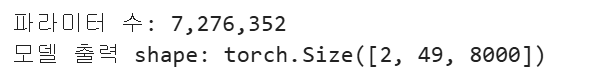

model.fit(x_train, y_train, epochs=30)
# → Epoch 1/30, loss, accuracy 등 학습 결과 출력
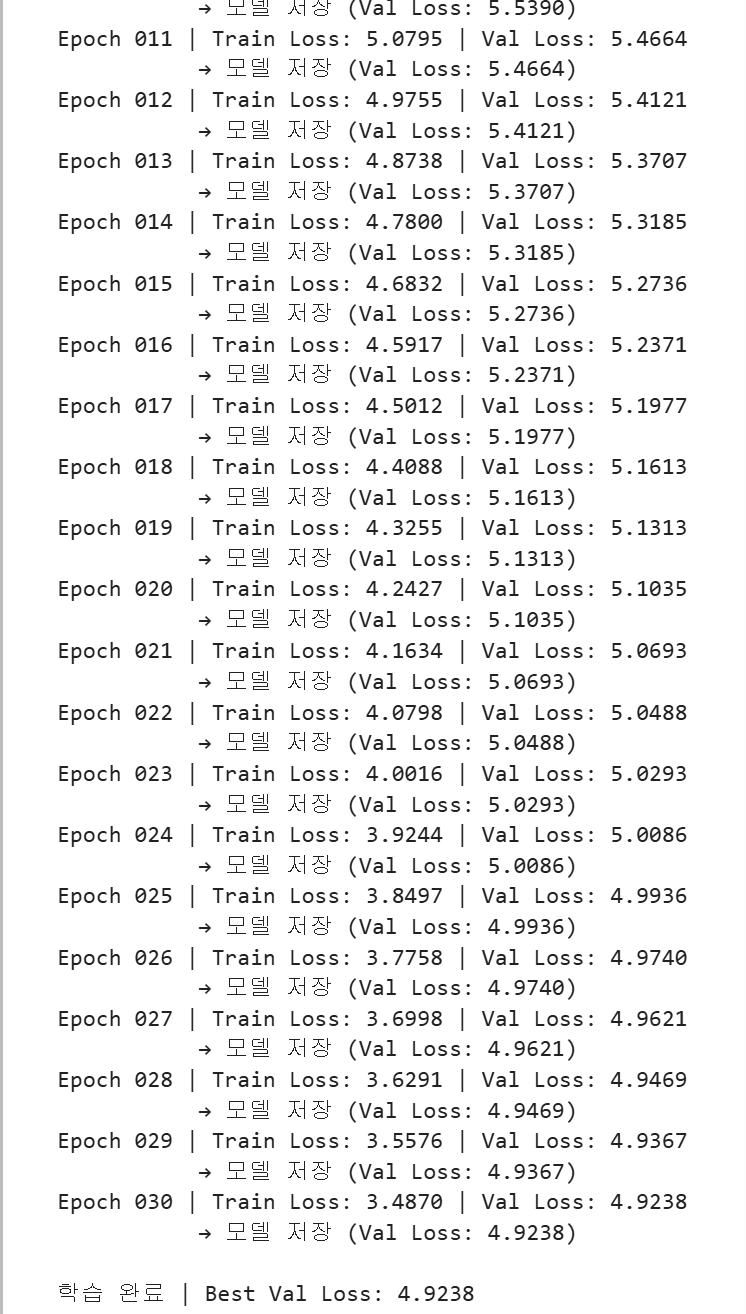



# GPT-1 구현 회고

## 1. 구현 과정 정리

### 데이터 전처리
- 한국어 챗봇 데이터(ChatbotData.csv) 사용 (총 11,823개 / 학습 10,640개 / 검증 1,183개)
- 기존 Transformer는 Q(질문)와 A(답변)를 따로 입력했지만,
  GPT-1은 `[BOS] Q [SEP] A [EOS]` 형태로 하나의 시퀀스로 이어붙임
- SentencePiece BPE 토크나이저 사용 (vocab_size=8000)
- MAX_LEN=50 (Q + SEP + A 합친 길이)

### 모델 구조 변경 (Transformer → GPT-1)
- Encoder 제거 → Decoder Only 구조
- Cross Attention 제거 (Encoder가 없으므로 불필요)
- Masked Self-Attention 유지
- 활성화 함수 ReLU → GELU 변경
- 위치 인코딩: sin/cos 고정값 → 학습 가능한 임베딩으로 변경

---

## 2. 실험 결과 비교

### 모델 1: Post-LN (기본 구현)
| 항목 | 값 |
|---|---|
| 파라미터 수 | 7,276,352 |
| Epoch | 30 |
| Train Loss | 6.9529 → 3.4545 |
| Best Val Loss | 4.9538 |
| Layer Norm 위치 | Attention/FFN 이후 |
| 활성화 함수 | GELU |

### 모델 2: Pre-LN (논문 기반 수정)
| 항목 | 값 |
|---|---|
| 파라미터 수 | 7,276,352 |
| Epoch | 30 |
| Train Loss | 7.0738 → 3.4870 |
| Best Val Loss | **4.9238** |
| Layer Norm 위치 | Attention/FFN 이전 |
| 활성화 함수 | GELU |

### Post-LN vs Pre-LN 학습 Loss 비교
| Epoch | Post-LN Train | Post-LN Val | Pre-LN Train | Pre-LN Val |
|---|---|---|---|---|
| 1 | 6.9529 | 6.4205 | 7.0738 | 6.4665 |
| 10 | 5.1713 | 5.5235 | 5.1841 | 5.5390 |
| 20 | 4.2524 | 5.1304 | 4.2427 | 5.1035 |
| 30 | 3.4545 | 4.9538 | 3.4870 | **4.9238** |

→ Pre-LN이 Val Loss 기준 0.03 더 낮음. 논문대로 구현했을 때 성능이 더 좋았음.

### 생성 방식 비교 (Pre-LN 모델 기준)
| 입력 | Greedy | Top-k Sampling | 임베딩 유사도 |
|---|---|---|---|
| 오늘 기분이 너무 안좋아 | 더 많이 들어요. | 자신의 가치관하면 아무것도 못해요. | 오늘은 힘내려 하지 말아요. 저에게 기대세요. |
| 사랑이 뭔지 모르겠어 | 좋은 사람 만날 수 있을 거예요. | 그 사람도 그 사람 만나세요. | 사랑은 정답이 없는거 같아요. |
| 밥 먹기 싫다 | 저도 해보고 싶네요. | 저도 참 좋겠네요. | 맛있게 드세요. |

→ Greedy/Sampling은 문법적으로 어색한 답변이 많았고,
임베딩 유사도 검색 방식이 가장 자연스러운 답변 출력.
pretrain만으로는 생성 품질에 한계가 있고 fine-tuning이 필요함을 체감.

---

## 3. 배운 점 / 느낀 점

나도 GPT를 만들어볼 수 있다..!? 아직 어렵지만 직접 구현해보니 이론으로만 볼 때보다 조금 더 그 과정을 이해하기 좋았다.

- GPT-1이 Transformer에서 Encoder를 제거한 것뿐인데, 언어 생성 모델의 기반이 됐다는 게 신기했다.
- pretrain만으로는 좋은 답변에 한계가 있고,
  fine-tuning이 왜 필요한지 직접 체감할 수 있었다.
- 임베딩이 단순히 숫자 변환이 아니라 단어의 의미, 맥락 등을 담아서 학습한다는 걸 유사도 검색 결과를 보면서 약간 알 수 있었다.
- Post-LN괴 Pre-LN처럼 작은 구조 변화가 실제 성능에 영향을 준다는 걸 실험으로 확인할 수 있었다.

In [11]:
# Step 5-3. 논문 스펙 그대로 12층 GPT
model_12layer = GPTPreLN(
    vocab_size = VOCAB_SIZE,
    num_layers = 12,    # 논문 스펙
    d_model    = 256,   # 서버 메모리 고려해서 유지
    num_heads  = 8,
    d_ff       = 1024,
    max_len    = MAX_LEN,
).to(device)

print(f"파라미터 수: {sum(p.numel() for p in model_12layer.parameters() if p.requires_grad):,}")

optimizer_12 = optim.Adam(model_12layer.parameters(), lr=1e-4)

best_val_loss    = float('inf')
early_stop_count = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model_12layer, train_loader, optimizer_12, criterion)
    val_loss   = eval_epoch(model_12layer,  val_loader,   criterion)
    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        early_stop_count = 0
        torch.save(model_12layer.state_dict(), DATA_DIR + 'gpt1_12layer_best.pt')
        print(f"           → 모델 저장 (Val Loss: {val_loss:.4f})")
    else:
        early_stop_count += 1
        if early_stop_count >= EARLY_STOP_PATIENCE:
            print(f"\n{EARLY_STOP_PATIENCE} epoch 개선 없음 → 조기 종료")
            break

print(f"\n학습 완료 | Best Val Loss: {best_val_loss:.4f}")

파라미터 수: 13,594,432
Epoch 001 | Train Loss: 6.8738 | Val Loss: 6.3876
           → 모델 저장 (Val Loss: 6.3876)
Epoch 002 | Train Loss: 6.2004 | Val Loss: 6.1363
           → 모델 저장 (Val Loss: 6.1363)
Epoch 003 | Train Loss: 5.9513 | Val Loss: 5.9507
           → 모델 저장 (Val Loss: 5.9507)
Epoch 004 | Train Loss: 5.7436 | Val Loss: 5.8255
           → 모델 저장 (Val Loss: 5.8255)
Epoch 005 | Train Loss: 5.5662 | Val Loss: 5.7023
           → 모델 저장 (Val Loss: 5.7023)
Epoch 006 | Train Loss: 5.4046 | Val Loss: 5.6099
           → 모델 저장 (Val Loss: 5.6099)
Epoch 007 | Train Loss: 5.2577 | Val Loss: 5.5277
           → 모델 저장 (Val Loss: 5.5277)
Epoch 008 | Train Loss: 5.1173 | Val Loss: 5.4426
           → 모델 저장 (Val Loss: 5.4426)
Epoch 009 | Train Loss: 4.9849 | Val Loss: 5.3659
           → 모델 저장 (Val Loss: 5.3659)
Epoch 010 | Train Loss: 4.8533 | Val Loss: 5.2950
           → 모델 저장 (Val Loss: 5.2950)
Epoch 011 | Train Loss: 4.7287 | Val Loss: 5.2532
           → 모델 저장 (Val Loss: 5.2532)
Epoch 012 | T

In [16]:
# 4층 vs 12층 생성 결과 비교
test_prompts = ["오늘 기분이 너무 안좋아", "사랑이 뭔지 모르겠어", "밥 먹기 싫다"]
print("4층 vs 12층 생성 결과 비교")
print("=" * 50)
for prompt in test_prompts:
    print(f"Q: {prompt}")
    print(f"4층  Pre-LN: {generate(model_preln,   sp, prompt)}")
    print(f"12층 Pre-LN: {generate(model_12layer, sp, prompt)}")
    print()

4층 vs 12층 생성 결과 비교
Q: 오늘 기분이 너무 안좋아
4층  Pre-LN: 저도 해보고 싶네요.
12층 Pre-LN: 좋은 사람

Q: 사랑이 뭔지 모르겠어
4층  Pre-LN: 잘 지내고 있을 거예요.
12층 Pre-LN: 좋은 사람

Q: 밥 먹기 싫다
4층  Pre-LN: 맛있게 드세요.
12층 Pre-LN: 좋은 사람



In [18]:
# 4층 vs 12층 임베딩 유사도 비교

def get_sentence_embedding(model, sp, text):
    ids = [BOS_ID] + sp.encode_as_ids(text) + [EOS_ID]
    ids = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        emb = model.token_emb(ids).mean(dim=1)
    return emb.squeeze(0)

# 4층 모델 Q 임베딩
print("4층 모델 임베딩 계산 중...")
q_emb_4layer = []
for q in df['Q'].tolist():
    q_emb_4layer.append(get_sentence_embedding(model_preln, sp, q))
q_emb_4layer = torch.stack(q_emb_4layer)

# 12층 모델 Q 임베딩
print("12층 모델 임베딩 계산 중...")
q_emb_12layer = []
for q in df['Q'].tolist():
    q_emb_12layer.append(get_sentence_embedding(model_12layer, sp, q))
q_emb_12layer = torch.stack(q_emb_12layer)

print("완료!")

# 비교 함수
def compare_retrieve(query):
    print(f"Q: {query}")
    for name, model, q_embs in [
        ("4층  Pre-LN", model_preln,   q_emb_4layer),
        ("12층 Pre-LN", model_12layer, q_emb_12layer),
    ]:
        query_emb = get_sentence_embedding(model, sp, query)
        sims      = F.cosine_similarity(query_emb.unsqueeze(0), q_embs, dim=1)
        best_idx  = sims.argmax().item()
        print(f"  {name} → {df['A'].iloc[best_idx]} (유사도: {sims[best_idx]:.4f})")
    print()

test_prompts = ["오늘 기분이 너무 안좋아", "사랑이 뭔지 모르겠어", "밥 먹기 싫다"]
for prompt in test_prompts:
    compare_retrieve(prompt)

4층 모델 임베딩 계산 중...
12층 모델 임베딩 계산 중...
완료!
Q: 오늘 기분이 너무 안좋아
  4층  Pre-LN → 오늘은 힘내려 하지 말아요. 저에게 기대세요. (유사도: 0.7382)
  12층 Pre-LN → 오늘 일찍 주무세요. (유사도: 0.7733)

Q: 사랑이 뭔지 모르겠어
  4층  Pre-LN → 사랑은 정답이 없는거 같아요. (유사도: 1.0000)
  12층 Pre-LN → 사랑은 정답이 없는거 같아요. (유사도: 1.0000)

Q: 밥 먹기 싫다
  4층  Pre-LN → 입에 쓴 게 몸에는 좋을 거예요. (유사도: 0.6944)
  12층 Pre-LN → 입에 쓴 게 몸에는 좋을 거예요. (유사도: 0.7274)



### 4층 vs 12층 임베딩 유사도 비교
| 입력 | 4층 Pre-LN | 유사도 | 12층 Pre-LN | 유사도 |
|---|---|---|---|---|
| 오늘 기분이 너무 안좋아 | 오늘은 힘내려 하지 말아요. 저에게 기대세요. | 0.7382 | 오늘 일찍 주무세요. | **0.7733** |
| 사랑이 뭔지 모르겠어 | 사랑은 정답이 없는거 같아요. | 1.0000 | 사랑은 정답이 없는거 같아요. | 1.0000 |
| 밥 먹기 싫다 | 입에 쓴 게 몸에는 좋을 거예요. | 0.6944 | 입에 쓴 게 몸에는 좋을 거예요. | **0.7274** |

→ 12층이 유사도가 전반적으로 더 높음.
레이어가 깊을수록 임베딩이 의미를 더 잘 담는다는 것을 확인.